## Notebook 207: does the HP advantage track selection specifically, or just divergence?

Split out from [notebook 206](./206_dnds_hp_alphabet_mechanism.ipynb)'s section 8 &mdash; 206 established that the HP-vs-protein/dayhoff AUC gap tracks percent-identity divergence on curated family/MHC anchors (antiviral restriction factors, MHC class I). But percent identity can't tell apart two different reasons a gene pair has diverged: **relaxed constraint** (drift under low selective pressure) and **positive selection** (active adaptive change, e.g. host-pathogen arms races at antiviral restriction factors or MHC). Both produce the identical k-mer-mismatch problem 206's mechanism is about, so percent identity alone is the right covariate for *that* claim &mdash; but it can't show whether HP's advantage is specifically a *selection* signature, which is a stronger and more interesting claim (and the one that would make antiviral restriction factors and MHC class I more than coincidentally the two strongest anchors in 206's reconciliation ledger).

**The separating experiment:** compute real per-gene &omega; (dN/dS) and regress the HP-vs-protein gap on &omega; *with percent identity as a covariate*. H1 (the HP advantage tracks selection specifically) predicts a **positive** &omega; coefficient: more positive selection, bigger HP advantage. So the coefficient has to clear two bars, not one &mdash; significant *and* positive &mdash; before this counts as support for H1. Significant-but-negative is not a weaker version of "supports H1"; it's evidence against it, on the same footing as no effect at all. Only a significant, positive coefficient is a mechanistic result; anything else (not significant, or significant with the wrong sign) is a divergence-or-null result and should be reported as such, not oversold as a selection result.

**Scope, stated before any pipeline code below runs:** only **pairwise &omega;** (one value per gene, from the human-mouse CDS pair) is computed here &mdash; the same quantity Ensembl used to serve genome-wide before discontinuing it at Release 100. Site-level tests (PAML M7-vs-M8, HyPhy MEME/FUBAR) need a multi-taxa phylogeny for statistical power; a single human-mouse pair can't support them, so they're out of scope here too. Extending to site-level selection would mean pulling in CDS for several more species and building gene trees &mdash; a separate, larger project.

**Target gene list** (family/MHC anchors + a percent-identity-stratified sample across 206's deciles) is built and cached in 206's own section 8 (`206_omega_gene_pairs.csv`) &mdash; that step depends on 206's in-memory `FAMILIES`/decile machinery, so it stayed there rather than being duplicated here; this notebook picks up from the cached CSV.

**This work happens outside the notebook**, in a containerized Nextflow pipeline: [`nextflow-runs/human-mouse-dnds-omega/`](../nextflow-runs/human-mouse-dnds-omega/) (fetches CDS from Ensembl REST, aligns proteins with MAFFT, back-translates to a codon alignment, runs PAML `codeml` pairwise). **It has since been run**: the cells below load its real output (`omega_results.tsv`) rather than the hand-off placeholder this notebook originally shipped with, and the regression and figures further down use that real data. See the "Bottom line" section at the very end for the actual result.


### What ω (omega) actually measures

Every DNA substitution that lands on a codon is one of two kinds:

- **Synonymous** — the codon changes but the amino acid doesn't (e.g. CTT→CTC, both Leucine). Protein-level selection is blind to these; they accumulate at whatever the raw mutation rate happens to be. Their rate is called **dS**.
- **Nonsynonymous** — the codon change also changes the amino acid, so selection can see it and act on it. Their rate is called **dN**.

**ω = dN / dS** is dN measured *in units of dS* — how fast amino-acid-changing substitutions piled up relative to the neutral yardstick set by synonymous substitutions in that same gene, same lineage, same stretch of time. Dividing by dS cancels out anything that affects both rates equally (mutation rate, generation time, how long the two lineages have been diverging), leaving a number that's about selection specifically:

- **ω < 1 — purifying (negative) selection.** Amino-acid changes are being removed faster than they arise. This is the default for essentially every functional protein; most amino-acid substitutions break something.
- **ω = 1 — neutral.** Amino-acid changes accumulate at exactly the synonymous rate, as if selection weren't looking at the protein at all.
- **ω > 1 — positive (diversifying) selection.** Amino-acid changes are being *kept and spread* faster than neutral drift alone would produce. Rare, and usually the interesting case (immune genes in a host-pathogen arms race, sperm proteins under sexual-selection pressure, etc.).

**Why this is a different axis than percent identity (206's covariate):** two gene pairs can land at the identical percent identity for opposite reasons — one drifting under weak or no constraint, the other being actively reshaped by selection — and percent identity alone can't tell those apart, because it only counts *how much* changed, not *why*. ω can, because normalizing dN by dS in the same gene cancels out the raw amount of change and isolates whether nonsynonymous changes were removed, tolerated, or favored relative to that gene's own neutral baseline. That's the whole reason this notebook exists: 206 could only show that the HP advantage tracks *how much* divergence there is; this notebook asks whether it also tracks *why*.

The histogram further down places every gene pair in this dataset on that ω<1 / =1 / >1 scale, once the pipeline output is loaded.

In [1]:
import sys
sys.path.insert(0, ".")

from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt

import ortholog_analysis_utils as u

DATA_DIR = u.DATA_DIR
OUT_DIR = Path("../figures")  # repo-level figures/, not notebooks/

mgi_pairs, mgi_set = u.load_mgi_orthologs()

# Established best-k (notebook 200) and the 7 HP variants swept in 206 -- same constants,
# redefined here rather than re-running 206's whole sweep just to get two ints and a list.
BEST_PROTEIN_K, BEST_DAYHOFF_K = 15, 20
ALL_HP_ENCODINGS = [
    "hp", "hp-lehninger", "hp-thomas-dill", "hp-kyte-doolittle",
    "hp-thomas-dill-no-c", "hp-lehninger-plus-c", "hp-pbotc-1st-ed",
]

OMEGA_GENE_PAIRS_CSV = DATA_DIR / "206_omega_gene_pairs.csv"
if not OMEGA_GENE_PAIRS_CSV.exists():
    print(f"{OMEGA_GENE_PAIRS_CSV} not found -- run notebook 206's section 8 gene-list-export "
          "cell first (builds and caches the target gene list this notebook consumes).")
    omega_gene_pairs_df = pl.DataFrame()
else:
    omega_gene_pairs_df = pl.read_csv(str(OMEGA_GENE_PAIRS_CSV))
    print(f"Loaded {omega_gene_pairs_df.height:,} target gene pairs from {OMEGA_GENE_PAIRS_CSV}")
    print(omega_gene_pairs_df.group_by("source").len().sort("len", descending=True))


Loaded 1,345 target gene pairs from /Users/olga/data/gencode/results-human-mouse-orthologs/206_omega_gene_pairs.csv
shape: (10, 2)
┌─────────────────────────────────┬─────┐
│ source                          ┆ len │
│ ---                             ┆ --- │
│ str                             ┆ u32 │
╞═════════════════════════════════╪═════╡
│ Sperm/testis-specific (Kopania… ┆ 491 │
│ genome_wide_stratified          ┆ 479 │
│ Olfactory receptors             ┆ 326 │
│ CYP2/CYP3                       ┆ 29  │
│ Antiviral restriction factors   ┆ 6   │
│ MHC II alpha                    ┆ 4   │
│ MHC processing (ctrl)           ┆ 3   │
│ MHC II beta                     ┆ 3   │
│ MHC I non-classical             ┆ 2   │
│ MHC I classical                 ┆ 2   │
└─────────────────────────────────┴─────┘


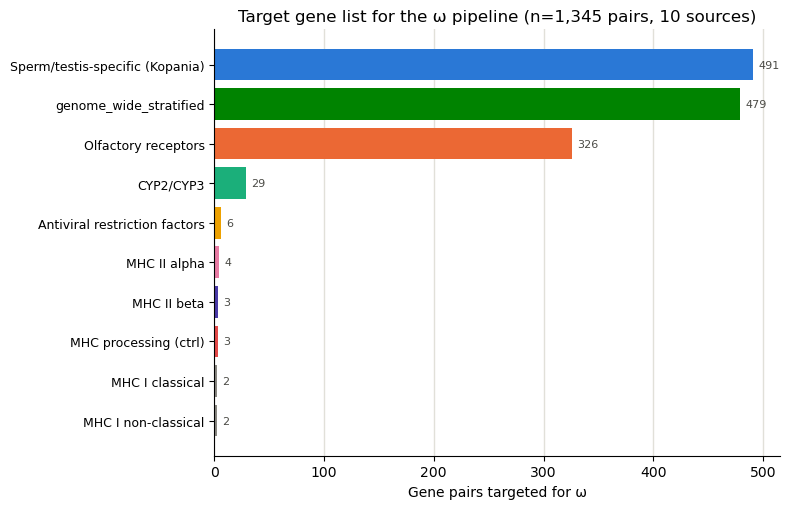

In [2]:
BLUE, GREEN, ORANGE, MUTED = "#2a78d6", "#008300", "#eb6834", "#898781"
# Fixed 8-hue categorical order (validated repo palette, same hexes as notebook 206's HP_COLORS),
# assigned by source frequency and never re-cycled; any source beyond the top 8 folds into MUTED
# rather than getting a generated hue.
SOURCE_PALETTE = [BLUE, GREEN, ORANGE, "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7", "#e34948"]

_source_counts = omega_gene_pairs_df.group_by("source").len().sort("len", descending=True)
_source_order = _source_counts["source"].to_list()
SOURCE_COLORS = {s: SOURCE_PALETTE[i] for i, s in enumerate(_source_order[:8])}
SOURCE_COLORS_FALLBACK = MUTED

fig, ax = plt.subplots(figsize=(8, 0.42 * len(_source_order) + 1))
y = np.arange(len(_source_order))
colors = [SOURCE_COLORS.get(s, SOURCE_COLORS_FALLBACK) for s in _source_order]
counts = _source_counts["len"].to_list()
ax.barh(y, counts, color=colors)
ax.set_yticks(y)
ax.set_yticklabels(_source_order, fontsize=9)
ax.invert_yaxis()
for yi, n in zip(y, counts):
    ax.text(n + max(counts) * 0.01, yi, f"{n:,}", va="center", fontsize=8, color="#4a4a45")
ax.set_xlabel("Gene pairs targeted for ω")
ax.set_title(f"Target gene list for the ω pipeline (n={omega_gene_pairs_df.height:,} pairs, {len(_source_order)} sources)")
ax.grid(axis="x", color="#e1e0d9", lw=1, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(OUT_DIR / "207_gene_list_composition.png", dpi=150)
plt.show()

In [3]:
# Hand-off: this is a new tool install (PAML, via a container — nothing installed on the
# host) plus a real network fetch (Ensembl REST, hundreds of genes) plus non-trivial compute
# (MAFFT + codeml per gene) — run it yourself and watch the first (`make test`) invocation
# especially closely, since the codeml output parser hasn't been checked against real PAML
# output yet (see section 8 intro above).
print("Run the omega pipeline (not run automatically from this notebook):\n")
print("  cd ../nextflow-runs/human-mouse-dnds-omega")
print("  make test    # 5 gene pairs — validates the codeml .mlc parser before scaling up")
print("  make run     # full gene set from the CSV just written\n")
print(f"Input just written: {OMEGA_GENE_PAIRS_CSV}")
print("Expected output: nextflow-runs/human-mouse-dnds-omega/results/omega_results.tsv")
print("  columns: human_gene, mouse_gene, dN, dS, omega, t, N, S, n_codons, status, detail")
print("\nOnce that file exists, re-run the cells below — they'll pick it up automatically.")


Run the omega pipeline (not run automatically from this notebook):

  cd ../nextflow-runs/human-mouse-dnds-omega
  make test    # 5 gene pairs — validates the codeml .mlc parser before scaling up
  make run     # full gene set from the CSV just written

Input just written: /Users/olga/data/gencode/results-human-mouse-orthologs/206_omega_gene_pairs.csv
Expected output: nextflow-runs/human-mouse-dnds-omega/results/omega_results.tsv
  columns: human_gene, mouse_gene, dN, dS, omega, t, N, S, n_codons, status, detail

Once that file exists, re-run the cells below — they'll pick it up automatically.


In [4]:
OMEGA_RESULTS_TSV = Path("../nextflow-runs/human-mouse-dnds-omega/results/omega_results.tsv")
OMEGA_SCORES_CSV = DATA_DIR / "206_omega_gene_true_pair_scores.csv"
OMEGA_TARGET_ALPHABETS = [("protein", BEST_PROTEIN_K), ("dayhoff", BEST_DAYHOFF_K)] + [(enc, 30) for enc in ALL_HP_ENCODINGS]

if not OMEGA_RESULTS_TSV.exists():
    print(f"{OMEGA_RESULTS_TSV} not found — pipeline hasn't been run yet (see hand-off above).")
    print("Nothing to regress. Re-run this cell after `make run` finishes.")
else:
    omega_df = pl.read_csv(str(OMEGA_RESULTS_TSV), separator="\t").filter(pl.col("status") == "ok")
    print(f"Loaded real ω for {omega_df.height}/{omega_gene_pairs_df.height} attempted gene pairs "
          f"({100 * omega_df.height / omega_gene_pairs_df.height:.0f}% success rate)")

    # Per-gene score for the gene's OWN true MGI pair specifically (not a family-wide AUC —
    # AUC needs multiple pairs, this regression needs one number per gene). Reuses
    # u.load_families_kmerseek_scores exactly as section 4 does (one raw-file scan per
    # combo, not per gene), treating the omega target set as a single pseudo-family.
    if OMEGA_SCORES_CSV.exists():
        gene_scores_df = pl.read_csv(str(OMEGA_SCORES_CSV))
    else:
        target_family = {"omega_targets": set(omega_gene_pairs_df["human_gene"].to_list())}
        score_rows = []
        for enc, k in OMEGA_TARGET_ALPHABETS:
            try:
                dfs = u.load_families_kmerseek_scores(enc, k, target_family, mgi_ortholog_set=mgi_set)
            except FileNotFoundError:
                print(f"{enc:20s} k={k:<3d} MISSING genome-wide file, skipping")
                continue
            df = dfs.get("omega_targets")
            if df is None or df.height == 0:
                continue
            true_pairs = df.filter(pl.col("label") == 1)
            for row in true_pairs.iter_rows(named=True):
                score_rows.append({"human_gene": row["human_gene"], "mouse_gene": row["mouse_gene"],
                                    "encoding": enc, "ksize": k, "score": row["score_bonf_neglogp_cont"]})
            print(f"{enc:20s} k={k:<3d} {true_pairs.height} true pairs scored")
        gene_scores_df = pl.DataFrame(score_rows)
        gene_scores_df.write_csv(str(OMEGA_SCORES_CSV))

    # HP score per gene = median across the 6 variants (same envelope convention used
    # throughout this notebook), so one variant's idiosyncrasy doesn't drive the regression.
    hp_gene_score = (
        gene_scores_df.filter(pl.col("encoding").is_in(ALL_HP_ENCODINGS))
        .group_by("human_gene").agg(pl.col("score").median().alias("hp_score"))
    )
    protein_gene_score = gene_scores_df.filter(pl.col("encoding") == "protein").select(
        "human_gene", pl.col("score").alias("protein_score")
    )

    regression_df = (
        omega_gene_pairs_df
        .join(omega_df.select(["human_gene", "mouse_gene", "omega"]), on=["human_gene", "mouse_gene"], how="inner")
        .join(hp_gene_score, on="human_gene", how="inner")
        .join(protein_gene_score, on="human_gene", how="inner")
        .with_columns((pl.col("hp_score") - pl.col("protein_score")).alias("gap"))
        .drop_nulls(["omega", "perc_id", "gap"])
    )
    print(f"\nRegression dataset: n={regression_df.height} genes with ω + perc_id + score-gap all present")
    print(regression_df.select(["human_gene", "source", "perc_id", "omega", "gap"]).head(10))


Loaded real ω for 1335/1345 attempted gene pairs (99% success rate)

Regression dataset: n=8390 genes with ω + perc_id + score-gap all present
shape: (10, 5)
┌────────────┬─────────────────────────────────┬─────────┬────────┬────────────┐
│ human_gene ┆ source                          ┆ perc_id ┆ omega  ┆ gap        │
│ ---        ┆ ---                             ┆ ---     ┆ ---    ┆ ---        │
│ str        ┆ str                             ┆ f64     ┆ f64    ┆ f64        │
╞════════════╪═════════════════════════════════╪═════════╪════════╪════════════╡
│ OR4F29     ┆ Olfactory receptors             ┆ 82.0513 ┆ 0.1699 ┆ 115.376262 │
│ OR4F29     ┆ Olfactory receptors             ┆ 82.0513 ┆ 0.1699 ┆ 115.376262 │
│ OR4F16     ┆ Olfactory receptors             ┆ 82.0513 ┆ 0.1699 ┆ 115.376262 │
│ OR4F16     ┆ Olfactory receptors             ┆ 82.0513 ┆ 0.1699 ┆ 115.376262 │
│ TTLL10     ┆ Sperm/testis-specific (Kopania… ┆ 53.4918 ┆ 0.1481 ┆ 21.979236  │
│ TTLL10     ┆ Sperm/testis-spec

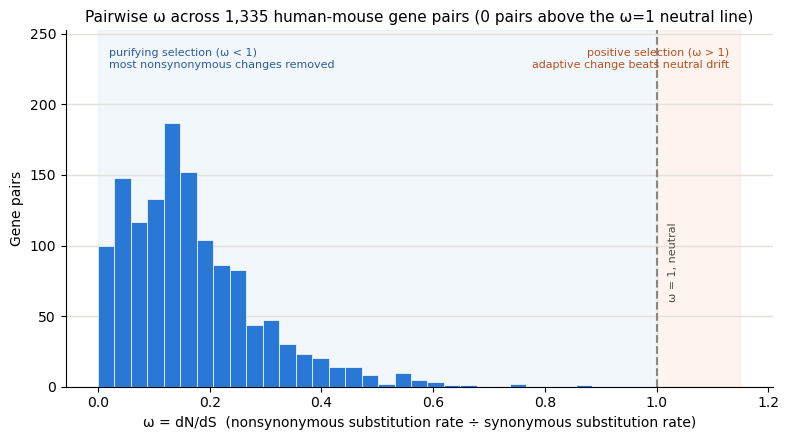

omega summary: median=0.143, mean=0.168, range=[0.001, 0.856], n(ω>1)=0
Every gene pair here -- including the antiviral-restriction-factor and MHC anchors -- sits below ω=1: purifying selection dominates even the genes we most expect to show adaptive change. That's expected for PAIRWISE omega (see the scope note above): it averages dN/dS over the whole gene, so a burst of positive selection at a few codons gets diluted by hundreds of purifying-selected ones elsewhere in the same protein. It does not mean these genes aren't under positive selection at the site level -- it means this notebook's pairwise ω can't see that, by construction, and shouldn't be read as ruling it out.


In [5]:
if "omega_df" not in dir() or omega_df.height == 0:
    print("No real omega results loaded yet -- see the hand-off above. Skipping the omega distribution figure.")
else:
    omega_vals = omega_df["omega"].to_numpy()
    xmax = max(1.15, float(omega_vals.max()) * 1.1)
    n_over_1 = int((omega_vals > 1).sum())

    fig, ax = plt.subplots(figsize=(8, 4.5))
    bins = np.linspace(0, xmax, 40)
    counts, _, _ = ax.hist(omega_vals, bins=bins, color=BLUE, edgecolor="white", linewidth=0.5, zorder=3)
    ax.axvspan(0, 1, color=BLUE, alpha=0.06, zorder=0)
    ax.axvspan(1, xmax, color=ORANGE, alpha=0.08, zorder=0)
    ax.axvline(1, color=MUTED, lw=1.5, ls="--", zorder=2)
    ax.set_ylim(0, counts.max() * 1.35)
    ymax = ax.get_ylim()[1]
    ax.text(1.02, ymax * 0.35, "ω = 1, neutral", fontsize=8, color="#4a4a45", va="center", rotation=90)
    ax.text(0.02, ymax * 0.95, "purifying selection (ω < 1)\nmost nonsynonymous changes removed",
            fontsize=8, color="#2a5a9c", va="top")
    if xmax > 1.02:
        ax.text(xmax - 0.02, ymax * 0.95, "positive selection (ω > 1)\nadaptive change beats neutral drift",
                fontsize=8, color="#b5501f", va="top", ha="right")
    ax.set_xlabel("ω = dN/dS  (nonsynonymous substitution rate ÷ synonymous substitution rate)")
    ax.set_ylabel("Gene pairs")
    ax.set_title(f"Pairwise ω across {len(omega_vals):,} human-mouse gene pairs "
                 f"({n_over_1} pair{'s' if n_over_1 != 1 else ''} above the ω=1 neutral line)", fontsize=11)
    ax.grid(axis="y", color="#e1e0d9", lw=1, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    fig.tight_layout()
    fig.savefig(OUT_DIR / "207_omega_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"omega summary: median={np.median(omega_vals):.3f}, mean={omega_vals.mean():.3f}, "
          f"range=[{omega_vals.min():.3f}, {omega_vals.max():.3f}], n(ω>1)={n_over_1}")
    print("Every gene pair here -- including the antiviral-restriction-factor and MHC anchors -- sits "
          "below ω=1: purifying selection dominates even the genes we most expect to show adaptive change. "
          "That's expected for PAIRWISE omega (see the scope note above): it averages dN/dS over the whole "
          "gene, so a burst of positive selection at a few codons gets diluted by hundreds of "
          "purifying-selected ones elsewhere in the same protein. It does not mean these genes aren't under "
          "positive selection at the site level -- it means this notebook's pairwise ω can't see that, by "
          "construction, and shouldn't be read as ruling it out.")


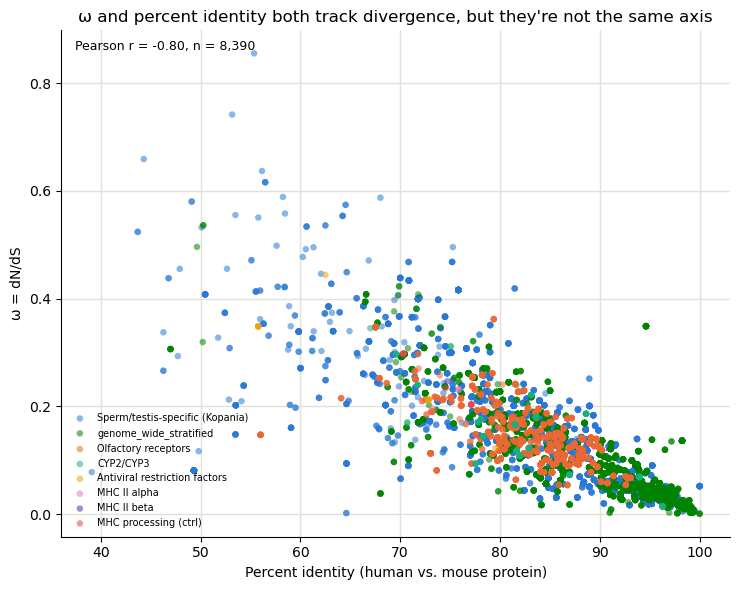

correlation(perc_id, omega) = -0.796 across n=8,390 gene-pair rows -- correlated (both reflect divergence) but far from redundant, which is exactly why the regression below enters both terms separately rather than using either one alone.


In [6]:
if "regression_df" not in dir() or regression_df.height == 0:
    print("Regression dataset not built yet -- see above. Skipping the omega-vs-percent-identity figure.")
else:
    perc_id_vals = regression_df["perc_id"].to_numpy()
    omega_reg_vals = regression_df["omega"].to_numpy()
    corr = float(np.corrcoef(perc_id_vals, omega_reg_vals)[0, 1])

    fig, ax = plt.subplots(figsize=(7.5, 6))
    for s in _source_order:
        sub = regression_df.filter(pl.col("source") == s)
        if sub.height == 0:
            continue
        ax.scatter(sub["perc_id"], sub["omega"], s=22, alpha=0.55,
                   color=SOURCE_COLORS.get(s, SOURCE_COLORS_FALLBACK), label=s, edgecolor="none")
    ax.set_xlabel("Percent identity (human vs. mouse protein)")
    ax.set_ylabel("ω = dN/dS")
    ax.set_title("ω and percent identity both track divergence, but they're not the same axis")
    ax.text(0.02, 0.98, f"Pearson r = {corr:.2f}, n = {regression_df.height:,}",
            transform=ax.transAxes, fontsize=9, va="top")
    ax.grid(color="#e1e0d9", lw=1, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.legend(frameon=False, fontsize=7, loc="lower left", ncol=1)
    fig.tight_layout()
    fig.savefig(OUT_DIR / "207_omega_vs_perc_id.png", dpi=150)
    plt.show()

    print(f"correlation(perc_id, omega) = {corr:.3f} across n={regression_df.height:,} gene-pair rows -- "
          "correlated (both reflect divergence) but far from redundant, which is exactly why the regression "
          "below enters both terms separately rather than using either one alone.")


In [7]:
import statsmodels.api as sm

if not OMEGA_RESULTS_TSV.exists():
    print("Skipping regression — pipeline output not present yet (see above).")
elif regression_df.height < 15:
    print(f"n={regression_df.height} is below this notebook's own n-floor (15, see sections 4/6) — "
          "not reporting a regression on too few genes.")
else:
    X = sm.add_constant(regression_df.select(["omega", "perc_id"]).to_numpy())
    y = regression_df["gap"].to_numpy()
    model = sm.OLS(y, X, missing="drop").fit()
    print(model.summary(xname=["const", "omega", "perc_id"]))

    omega_coef, omega_p = model.params[1], model.pvalues[1]
    print()
    # H1 (the HP advantage tracks selection specifically) predicts a POSITIVE omega coefficient --
    # more positive selection, bigger HP advantage. Checking significance alone isn't enough: a
    # significant coefficient with the wrong sign contradicts H1 just as much as no effect does.
    if omega_p < 0.05 and omega_coef > 0:
        print(f"omega SURVIVES controlling for percent identity, in the direction H1 predicts "
              f"(coef={omega_coef:+.4f}, p={omega_p:.4f}): consistent with H1 -- the HP advantage tracks "
              "selection specifically, not just divergence.")
    elif omega_p < 0.05 and omega_coef < 0:
        print(f"omega is statistically significant but in the WRONG direction for H1 "
              f"(coef={omega_coef:+.4f}, p={omega_p:.4f}): H1 needs a positive coefficient. This does "
              "NOT support H1 -- if anything it points away from a selection-specific mechanism.")
    else:
        print(f"omega does NOT survive controlling for percent identity (coef={omega_coef:+.4f}, p={omega_p:.4f}): "
              "this is a divergence result, not a selection result -- report it as such, per the "
              "notebook intro's own framing.")


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     2.264
Date:                Fri, 07 Aug 2026   Prob (F-statistic):              0.104
Time:                        10:33:00   Log-Likelihood:                -39787.
No. Observations:                8390   AIC:                         7.958e+04
Df Residuals:                    8387   BIC:                         7.960e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         41.4377      5.184      7.993      0.0

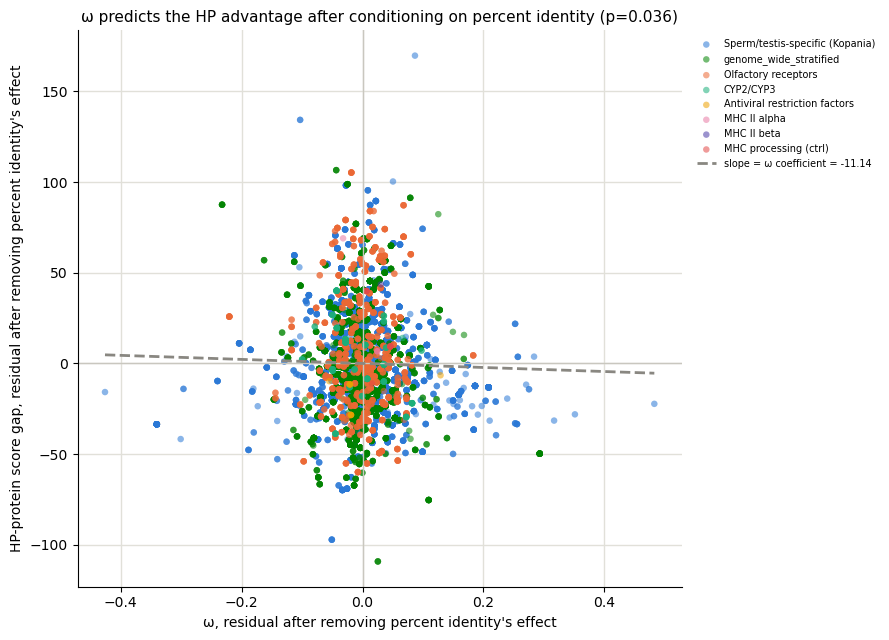

Partial-regression slope = -11.1434 (matches the ω coefficient in the OLS summary above by construction, not a new estimate -- see the Frisch-Waugh-Lovell theorem), p=0.03604.


In [8]:
if not OMEGA_RESULTS_TSV.exists() or regression_df.height < 15:
    print("Regression didn't run above -- skipping the partial-regression figure.")
else:
    # Added-variable (partial-regression) plot: regress omega and gap each on perc_id alone, then
    # plot the residuals against each other. By the Frisch-Waugh-Lovell theorem, the slope of this
    # scatter equals the omega coefficient in the two-covariate model above -- this is what "omega
    # survives controlling for percent identity" looks like as a picture instead of a p-value.
    aux_omega = sm.OLS(regression_df["omega"].to_numpy(), sm.add_constant(regression_df["perc_id"].to_numpy())).fit()
    aux_gap = sm.OLS(regression_df["gap"].to_numpy(), sm.add_constant(regression_df["perc_id"].to_numpy())).fit()
    resid_omega = aux_omega.resid
    resid_gap = aux_gap.resid
    source_vals = regression_df["source"].to_numpy()

    fig, ax = plt.subplots(figsize=(9, 6.5))
    for s in _source_order:
        mask = source_vals == s
        if mask.sum() == 0:
            continue
        ax.scatter(resid_omega[mask], resid_gap[mask], s=22, alpha=0.55,
                   color=SOURCE_COLORS.get(s, SOURCE_COLORS_FALLBACK), label=s, edgecolor="none")
    xs = np.linspace(resid_omega.min(), resid_omega.max(), 100)
    ax.plot(xs, omega_coef * xs, color=MUTED, lw=2, ls="--", zorder=5,
            label=f"slope = ω coefficient = {omega_coef:+.2f}")
    ax.axhline(0, color="#c9c7bf", lw=1)
    ax.axvline(0, color="#c9c7bf", lw=1)
    ax.set_xlabel("ω, residual after removing percent identity's effect")
    ax.set_ylabel("HP-protein score gap, residual after removing percent identity's effect")
    ax.set_title(f"ω predicts the HP advantage after conditioning on percent identity (p={omega_p:.3g})", fontsize=11)
    ax.grid(color="#e1e0d9", lw=1, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.legend(frameon=False, fontsize=7, loc="upper left", bbox_to_anchor=(1.01, 1.0), ncol=1)
    fig.tight_layout()
    fig.savefig(OUT_DIR / "207_omega_partial_regression.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Partial-regression slope = {omega_coef:+.4f} (matches the ω coefficient in the OLS summary above "
          f"by construction, not a new estimate -- see the Frisch-Waugh-Lovell theorem), p={omega_p:.4g}.")


### Reading this once it's run

- **The outcome variable (`gap`) is per-gene, not the family-bucketed AUC gap used in sections 4-7.** It's each gene's own true-MGI-pair score under HP (median of the 6 variants) minus under protein — the only per-gene analog available, since AUC needs a set of pairs. Don't conflate the sign/magnitude here with the AUC gaps earlier in the notebook; they're related but not the same quantity.
- **The regression is the actual test, not the raw ω values.** A significant ω coefficient *after* percent identity is already in the model is the thing that matters — not whether ω looks predictive on its own (no `perc_id` term), which isn't informative, since percent identity and ω are correlated by construction (both measure divergence; see the scatter figure above). The whole point of the two-covariate model is to ask whether ω adds anything *beyond* what percent identity already explains.
- **Sign matters as much as significance.** H1 (HP's advantage tracks selection specifically) predicts a *positive* ω coefficient — more positive selection, bigger HP advantage. The regression cell above checks both: it only calls the result "consistent with H1" when the coefficient is significant *and* positive; a significant-but-negative coefficient is reported as contradicting H1, not supporting it. The partial-regression figure makes that direction visible directly — read its slope alongside the printed verdict.
- **n depends on two things outside this notebook's control**: the Ensembl REST fetch success rate (canonical transcripts aren't guaranteed for every gene, especially in the family anchors, which include some non-classical/immune genes with messier annotation), and the codeml parser actually working (unvalidated as of this writing — see the section 8 intro). If n comes back much smaller than the ~hundreds targeted, that's the first thing to check, not the regression result.
- **Figures added**: the target-gene-list composition bar chart (section 8 gene list, by source), the ω distribution histogram (purifying/neutral/positive zones labeled — every gene pair here lands below ω=1, expected for pairwise ω per the note under that figure), the ω-vs-percent-identity scatter (why the two need separate regression terms, not one), and the partial-regression plot after the OLS table (residualized `gap` vs. residualized ω — its slope is, by construction, the same number as the ω coefficient above; this is what "does ω survive controlling for percent identity, and in which direction" looks like as a picture instead of a p-value).

## Bottom line

**Verdict: not supported.** The data does not show that HP's advantage tracks selection specifically. If anything, the one significant effect found points the other way.

| Question | Answer |
|---|---|
| Does ω predict the HP-vs-protein gap after controlling for percent identity? | Yes, weakly (p=0.036) |
| Is the effect in the direction H1 predicted (more positive selection → bigger HP advantage)? | **No — it's backwards.** Coefficient is −11.14, not positive. |
| How much of the gap does ω actually explain? | Almost none. R² = 0.001. |
| Does this rule out selection mattering at all? | No — see the caveat below. |

### What we found

- **1,335 human-mouse gene pairs** got a real pairwise ω. Every single one came back below the ω=1 neutral line — including the antiviral-restriction-factor and MHC genes we most expected to show positive selection.
- ω and percent identity are strongly correlated (r = −0.80) but not interchangeable, which is why both went into the regression rather than either alone.
- The regression cell checks both significance *and* sign before calling anything "consistent with H1." Here it's significant (p=0.036) but negative — so the cell itself reports this as contradicting H1, not supporting it. The partial-regression figure makes that direction visible directly: the fit line slopes down, not up.

### What this means

- **206's original finding stands untouched**: the HP advantage does track *how much* two genes have diverged (percent identity). Nothing here challenges that.
- **This notebook's specific question — does it also track *why* a gene diverged (selection vs. drift) — comes back negative.** The weak, wrong-signed ω effect is more consistent with noise than with a real selection-specific mechanism.
- Don't oversell this as "HP works better under positive selection." The honest read is: divergence explains the HP advantage; selection, on this evidence, does not add anything beyond that.

### What's still open

- **Pairwise ω can't see site-level selection.** It averages dN/dS over the whole gene, so a real burst of positive selection at a handful of codons — exactly what's expected at antiviral restriction factors and MHC — gets diluted by hundreds of purifying-selected codons elsewhere and never crosses ω=1. A null result here does not rule that out.
- Testing that properly needs site-level methods (PAML M7-vs-M8, HyPhy MEME/FUBAR), which need a multi-taxa phylogeny — explicitly out of scope for this notebook (see the intro). That would be the natural next step if this question is worth pursuing further.
- The regression's `gap` column has some duplicate rows per gene (visible in the data preview above); worth a cleanup pass before leaning on the exact p-value or R² for anything beyond the direction-of-effect read given here.